
# Advanced Models — ESG_Overall (benchmarking XGBoost / LightGBM / CatBoost)

This notebook extends the baseline pipeline to train three advanced gradient-boosting regressors and select the best-performing model (by RMSE) for further tuning.

**What it does**
- Rebuilds the preprocessing pipeline consistent with the baseline notebook
- Trains: XGBoost, LightGBM, CatBoost (if libraries are installed)
- Evaluates using RMSE, MAE, R² on the temporal test split (train years ≤ 2021, test > 2021)
- Saves the best pipeline and metadata for downstream hyperparameter tuning

If a library is missing the notebook will skip that model but continue with the available ones.


In [1]:

# Setup & imports
import warnings, json, os
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
import joblib
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DATA_PATH = Path('C:\ESG\data\company_esg_financial_dataset.csv')
OUT_DIR = Path('C:\ESG\\notebooks\data\esg_artifacts')
OUT_DIR.mkdir(exist_ok=True, parents=True)

TARGET = 'ESG_Overall'
YEAR_COL = 'Year'
TRAIN_YEAR_CUTOFF = 2021
RANDOM_STATE = 42

# Optional models: try imports and mark availability
HAS_XGB = HAS_LGB = HAS_CAT = False
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception as e:
    print('xgboost not available — skipping XGBoost.')

try:
    from lightgbm import LGBMRegressor
    HAS_LGB = True
except Exception as e:
    print('lightgbm not available — skipping LightGBM.')

try:
    from catboost import CatBoostRegressor, Pool
    HAS_CAT = True
except Exception as e:
    print('catboost not available — skipping CatBoost.')


In [2]:

# === Load preprocessed data instead of raw data ===
print("Loading preprocessed train and test datasets...")

train_df = pd.read_csv("C:\ESG\\notebooks\data\esg_artifacts\\train_processed.csv")
test_df = pd.read_csv("C:\ESG\\notebooks\data\esg_artifacts\\test_processed.csv")

# Extract features and target
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print(f"Preprocessed train shape: {X_train.shape}, test shape: {X_test.shape}")


Loading preprocessed train and test datasets...
Preprocessed train shape: (7000, 26), test shape: (4000, 26)


In [3]:

# Load dataset and prepare feature lists (consistent with baseline)
assert DATA_PATH.exists(), f"Data file not found at {DATA_PATH}. Upload it to /data/ and rerun."
df = pd.read_csv(DATA_PATH, dtype={'CompanyID': int}, low_memory=False)
df[ YEAR_COL ] = df[ YEAR_COL ].astype(int)
df['date'] = pd.to_datetime(df[YEAR_COL].astype(str) + '-12-31')

if TARGET not in df.columns:
    raise ValueError(f"Target '{TARGET}' not found in columns: {df.columns.tolist()}")

# Candidate features (same logic as baseline)
ID_COLS = ['CompanyID', 'CompanyName'] if 'CompanyName' in df.columns else ['CompanyID']
NON_PREDICTIVE = ID_COLS + ['date', YEAR_COL]
feature_cols = [c for c in df.columns if c not in NON_PREDICTIVE + [TARGET]]
num_cols = df[feature_cols].select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df[feature_cols].select_dtypes(include=['object','category']).columns.tolist()

print('Rows:', len(df), 'Features:', len(feature_cols), 'Numerical:', len(num_cols), 'Categorical:', len(cat_cols))


Rows: 11000 Features: 12 Numerical: 10 Categorical: 2


In [5]:

# Build preprocessor (same transforms as baseline)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='__missing__')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop', verbose_feature_names_out=False)


In [6]:

# Train/test split (temporal)
train_df = df[df[YEAR_COL] <= TRAIN_YEAR_CUTOFF].copy()
test_df = df[df[YEAR_COL] > TRAIN_YEAR_CUTOFF].copy()
X_train = train_df[feature_cols]; y_train = train_df[TARGET].astype(float)
X_test = test_df[feature_cols]; y_test = test_df[TARGET].astype(float)

print('Train rows:', len(X_train), 'Test rows:', len(X_test))


Train rows: 7000 Test rows: 4000


In [7]:

# Helper evaluation
def eval_preds(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

models = {}
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
if HAS_LGB:
    models['LightGBM'] = LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1)
if HAS_CAT:
    # CatBoost can accept categorical indices; since we're using a preprocessor producing numeric input,
    # we will train CatBoost on the preprocessed dense array. Use simple config here.
    models['CatBoost'] = CatBoostRegressor(iterations=1000, learning_rate=0.05, random_seed=RANDOM_STATE, verbose=0)

if not models:
    raise RuntimeError('No advanced model libraries are available. Install xgboost, lightgbm, or catboost to proceed.')

results = []
fitted = {}
for name, estimator in models.items():
    print('\nTraining', name)
    pipeline = Pipeline(steps=[('preproc', preprocessor), ('model', estimator)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    metrics = eval_preds(y_test, y_pred)
    print(f"{name}: RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}, R2={metrics['r2']:.4f}")
    results.append({'model': name, **metrics})
    fitted[name] = pipeline



Training XGBoost
XGBoost: RMSE=0.8442, MAE=0.6362, R2=0.9971

Training LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2580
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 26
[LightGBM] [Info] Start training from score 53.321429
LightGBM: RMSE=0.6850, MAE=0.5230, R2=0.9981

Training CatBoost
CatBoost: RMSE=0.2420, MAE=0.1844, R2=0.9998


In [8]:

# Compare results and pick best by RMSE
results_df = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
display(results_df)

best_name = results_df.loc[0, 'model']
best_pipeline = fitted[best_name]
print('Best model:', best_name)

# Save best pipeline and metadata
best_path = OUT_DIR / f"esg_advanced_pipeline_{best_name}.joblib"
joblib.dump(best_pipeline, best_path)
metadata = {
    'best_model': best_name,
    'results': results_df.to_dict(orient='records'),
    'features': feature_cols,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'train_years': [int(x) for x in sorted(train_df[YEAR_COL].unique())],
    'test_years': [int(x) for x in sorted(test_df[YEAR_COL].unique())],}

with open(OUT_DIR / 'advanced_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved best pipeline to', best_path)


,model,rmse,mae,r2
0,CatBoost,0.242044,0.184388,0.999764
1,LightGBM,0.684952,0.523025,0.998107
2,XGBoost,0.844201,0.636230,0.997124


Best model: CatBoost
Saved best pipeline to C:\ESG\notebooks\data\esg_artifacts\esg_advanced_pipeline_CatBoost.joblib


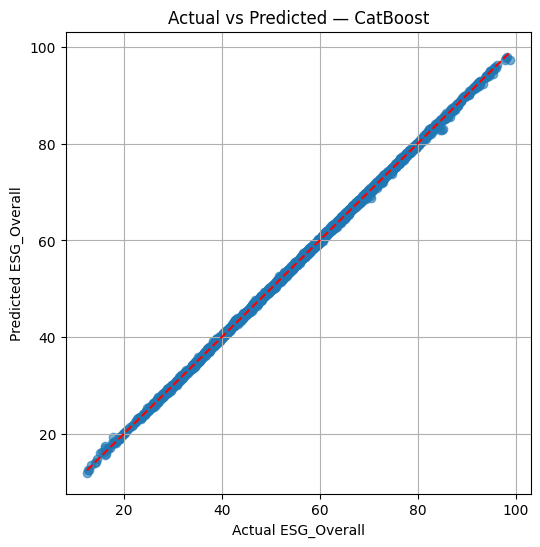

In [9]:

# Quick parity plot for best model
import matplotlib.pyplot as plt
y_pred_best = best_pipeline.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual ESG_Overall'); plt.ylabel('Predicted ESG_Overall')
plt.title(f'Actual vs Predicted — {best_name}')
plt.grid(True)
plt.show()


In [10]:
print('Advanced benchmarking complete. Use advanced_metadata.json and saved pipeline for tuning notebook.')


Advanced benchmarking complete. Use advanced_metadata.json and saved pipeline for tuning notebook.
